# Titanic Survival Classification  --TASK 1
# **BY: MARYAM MUZAMMIL**

**Internship Task 1 | Arch Technologies**

Objective: Predict whether a passenger survived the Titanic disaster using machine learning.
Steps: Data Loading → EDA → Cleaning → Preprocessing → Model Training → Evaluation → Comparison

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset

In [2]:
# Loading Titanic dataset from seaborn (no file download needed)
df = sns.load_dataset('titanic')
print('Dataset Shape:', df.shape)
df.head(10)

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 3: Exploratory Data Analysis (EDA)

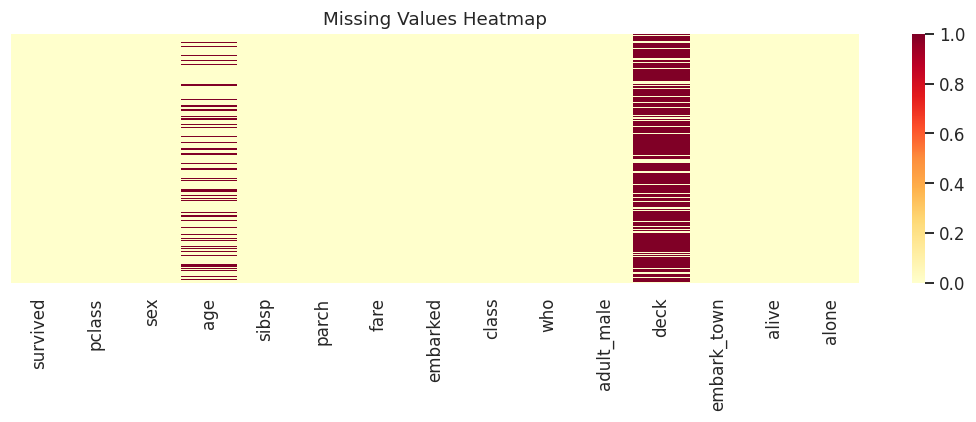

Missing value counts:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
# Missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, cmap='YlOrRd', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

print('Missing value counts:')
print(df.isnull().sum())

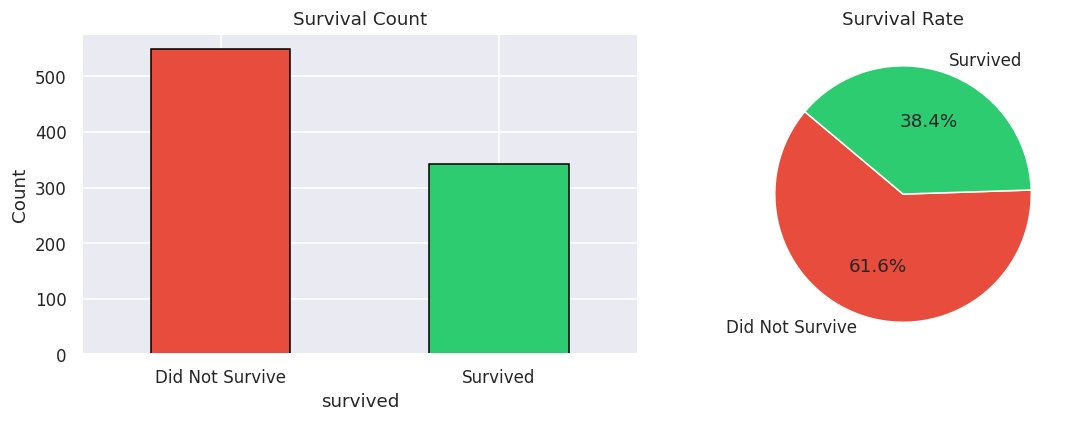

In [6]:
# Survival distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df['survived'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'], rotation=0)
axes[0].set_ylabel('Count')

df['survived'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Did Not Survive', 'Survived'],
    colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Survival Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

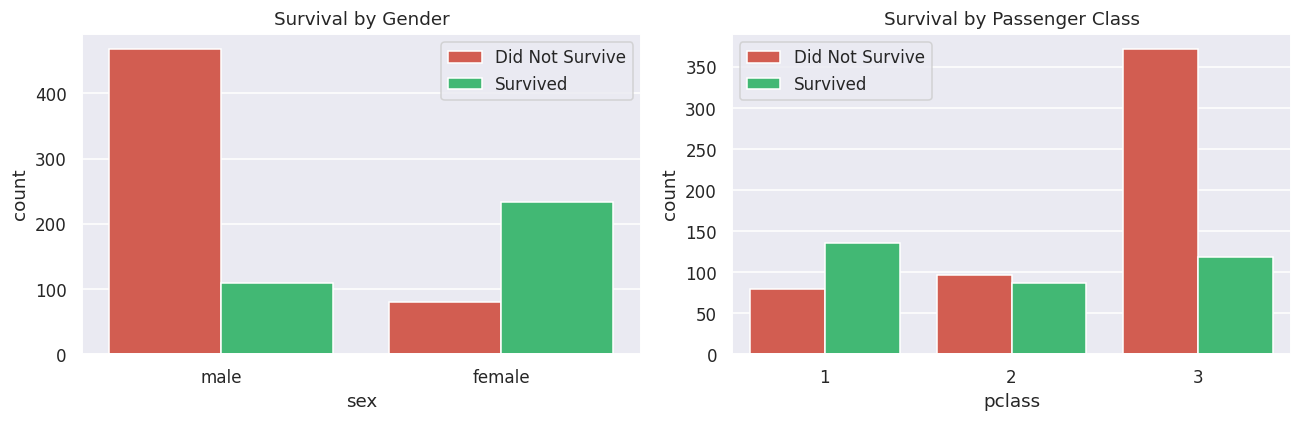

In [7]:
# Survival by gender and class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='sex', hue='survived', ax=axes[0],
              palette={0: '#E74C3C', 1: '#2ECC71'})
axes[0].set_title('Survival by Gender')
axes[0].legend(['Did Not Survive', 'Survived'])

sns.countplot(data=df, x='pclass', hue='survived', ax=axes[1],
              palette={0: '#E74C3C', 1: '#2ECC71'})
axes[1].set_title('Survival by Passenger Class')
axes[1].legend(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

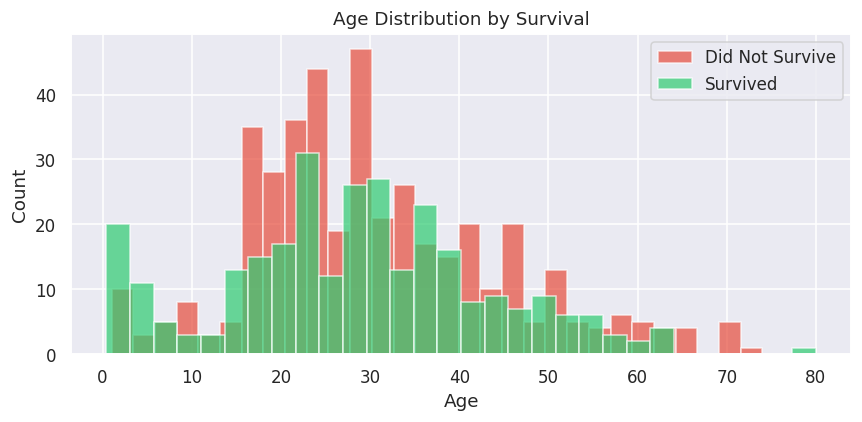

In [8]:
# Age distribution by survival
plt.figure(figsize=(8, 4))
df[df['survived'] == 0]['age'].dropna().hist(bins=30, alpha=0.7, color='#E74C3C', label='Did Not Survive')
df[df['survived'] == 1]['age'].dropna().hist(bins=30, alpha=0.7, color='#2ECC71', label='Survived')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

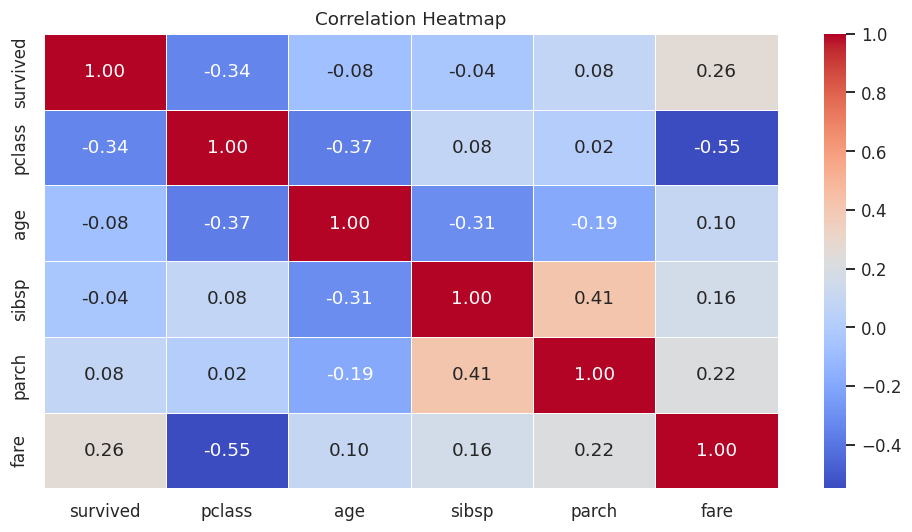

In [10]:
# Correlation heatmap
plt.figure(figsize=(9, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 4: Data Cleaning

In [11]:
df_clean = df.copy()

# Drop columns that are not useful for modeling
df_clean.drop(columns=['deck', 'embark_town', 'who', 'adult_male', 'alone', 'alive'], inplace=True)

# Fill missing age with median
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

# Fill missing embarked with mode
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
dtype: int64


## Step 5: Preprocessing

In [13]:
# Encode categorical columns
le = LabelEncoder()
df_clean['sex_encoded']      = le.fit_transform(df_clean['sex'])       # female=0, male=1
df_clean['embarked_encoded'] = le.fit_transform(df_clean['embarked'])  # C=0, Q=1, S=2

# Family size
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

# Select features and target
features = ['pclass', 'sex_encoded', 'age', 'fare', 'embarked_encoded', 'family_size']
X = df_clean[features]
y = df_clean['survived']

print('Features:', features)
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['pclass', 'sex_encoded', 'age', 'fare', 'embarked_encoded', 'family_size']
X shape: (891, 6)
y shape: (891,)


In [14]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 712
Testing samples : 179


## Step 6: Train Models
Two models are trained: Decision Tree and Random Forest. Both are compared to select the better one.

In [15]:
# Model 1: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)
dt_acc  = accuracy_score(y_test, dt_pred)
dt_auc  = roc_auc_score(y_test, dt_model.predict_proba(X_test_scaled)[:, 1])

print('Decision Tree')
print('Accuracy :', round(dt_acc, 4))
print('ROC-AUC  :', round(dt_auc, 4))

Decision Tree
Accuracy : 0.8212
ROC-AUC  : 0.8083


In [16]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

print('Random Forest')
print('Accuracy :', round(rf_acc, 4))
print('ROC-AUC  :', round(rf_auc, 4))

Random Forest
Accuracy : 0.8101
ROC-AUC  : 0.837


## Step 7: Model Evaluation

In [17]:
# Classification reports
print('===== Decision Tree =====')
print(classification_report(y_test, dt_pred, target_names=['Did Not Survive', 'Survived']))

print('===== Random Forest =====')
print(classification_report(y_test, rf_pred, target_names=['Did Not Survive', 'Survived']))

===== Decision Tree =====
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.86      0.86       110
       Survived       0.78      0.75      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179

===== Random Forest =====
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



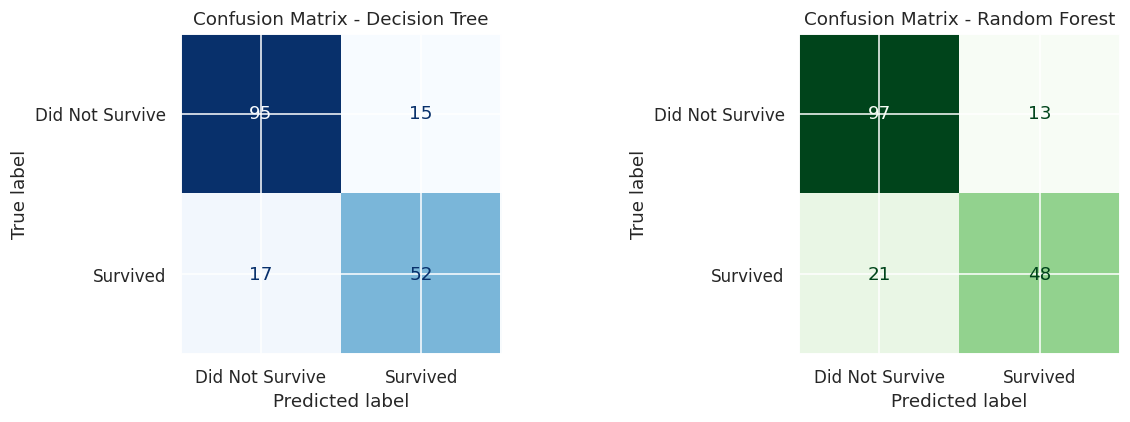

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, dt_pred),
    display_labels=['Did Not Survive', 'Survived']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Decision Tree')

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred),
    display_labels=['Did Not Survive', 'Survived']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.show()

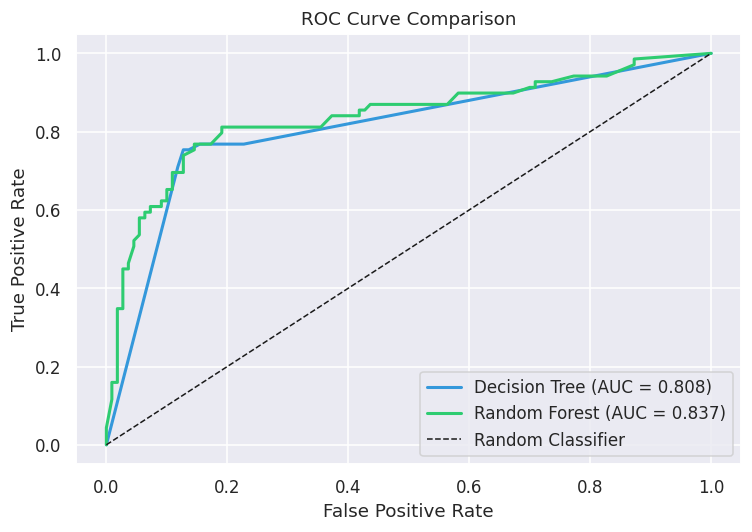

In [19]:
# ROC Curves - both models on same plot
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_model.predict_proba(X_test_scaled)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(7, 5))
plt.plot(dt_fpr, dt_tpr, color='#3498DB', lw=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, color='#2ECC71', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 8: Model Comparison & Conclusion

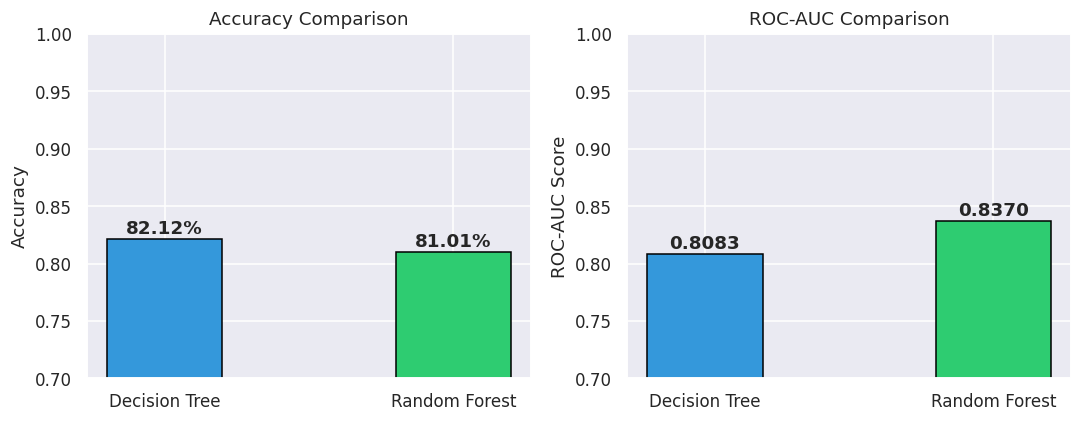

In [20]:
# Accuracy comparison bar chart
model_names = ['Decision Tree', 'Random Forest']
accuracies  = [dt_acc, rf_acc]
aucs        = [dt_auc, rf_auc]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(model_names, accuracies, color=['#3498DB', '#2ECC71'], edgecolor='black', width=0.4)
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 1.0)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

axes[1].bar(model_names, aucs, color=['#3498DB', '#2ECC71'], edgecolor='black', width=0.4)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.7, 1.0)
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

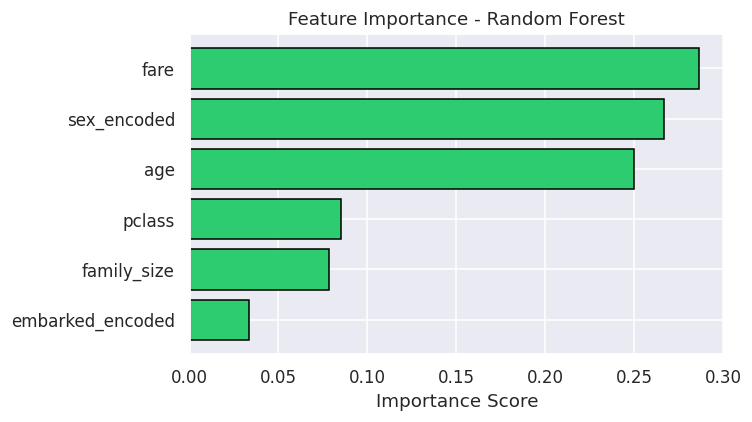

In [21]:
# Feature importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2ECC71', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [22]:
# Final summary
comparison = pd.DataFrame({
    'Model'       : ['Decision Tree', 'Random Forest'],
    'Accuracy'    : [round(dt_acc, 4), round(rf_acc, 4)],
    'ROC-AUC'     : [round(dt_auc, 4), round(rf_auc, 4)]
})

print('Model Comparison:')
print(comparison.to_string(index=False))

best = 'Random Forest' if rf_acc >= dt_acc else 'Decision Tree'
print(f'\nBetter Model: {best}')
print('Random Forest generally performs better because it uses multiple decision trees')
print('and combines their results, which reduces overfitting and improves accuracy.')

Model Comparison:
        Model  Accuracy  ROC-AUC
Decision Tree    0.8212   0.8083
Random Forest    0.8101   0.8370

Better Model: Decision Tree
Random Forest generally performs better because it uses multiple decision trees
and combines their results, which reduces overfitting and improves accuracy.
